# Decision Tree Hyperparameter Search for EVAL1/EVAL2

Input datasets are the ones used by `demo.ipynb`:

- EVAL1: `datasets/decisiontree/normalized/permute_*.csv`
- EVAL2: `prediction/datasets/decisiontree/normalized/permute_*.csv`

The search grid matches `miao-journal-improvement.ipynb` / `OUTPUT_GRID_DIR=split5_leaf5_30`: 49,920 candidates per eval.


In [1]:
from pathlib import Path
import importlib
import sys

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "demo.ipynb").exists():
    ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "demo.ipynb").exists())

sys.path.insert(0, str(ROOT))
import decision_tree_hyperparameter_search as dths
dths = importlib.reload(dths)

OUT_DIR = dths.output_dir(ROOT)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("repo root:", ROOT)
print("output dir:", OUT_DIR)
print("candidate count per eval:", dths.expected_candidate_count())
assert dths.expected_candidate_count() == 49920

# Selected hyperparameters used for the `selected` column and robustness diagnostics.
# Edit this cell in the notebook when you want to evaluate a different selected tree
# without changing the 49,920-candidate search grid.
SELECTED_PARAMS = {
    "eval1": {
        "criterion": "gini",
        'max_depth': 3,
        'min_samples_split': 15,
        'min_samples_leaf': 19,
        "max_leaf_nodes": None,
        "min_impurity_decrease": 0.0,
        "ccp_alpha": 0.0,
        "class_weight": "balanced",
        "random_state": 42,
    },
    "eval2": {
        "criterion": "gini",
        "max_depth": 4,
        "min_samples_split": 20,
        "min_samples_leaf": 5,
        "max_leaf_nodes": None,
        "min_impurity_decrease": 0.0,
        "ccp_alpha": 0.005,
        "class_weight": "balanced",
        "random_state": 42,
    },
}


repo root: /Users/noppoman/WorkingPlace/program/research/4896c62de389fa8a7ffca8a727d8f71f
output dir: /Users/noppoman/WorkingPlace/program/research/4896c62de389fa8a7ffca8a727d8f71f/decision_tree_hparam_search_out
candidate count per eval: 49920


## Run Search

`force=False` reuses compatible 49,920-candidate CSVs copied from `OUTPUT_GRID_DIR=split5_leaf5_30`. Existing 768/11,520-candidate CSVs are ignored because they do not have the matching `grid_id` and row count.


In [2]:
results = dths.run_all(
    root=ROOT,
    out_dir=OUT_DIR,
    selected_params=SELECTED_PARAMS,
    force=False,
    skip_robustness=False,
    progress_every=250,
    robustness_repeats=20,
    robustness_permutations=100,
)

eval1: using compatible cache with 49920 candidates: decision_tree_hparam_search_out/eval1_hyperparameter_search.csv
eval2: using compatible cache with 49920 candidates: decision_tree_hparam_search_out/eval2_hyperparameter_search.csv


## Feature-Importance Family Position

This table shows the search-space distribution of feature-importance mass by direction family, and where the selected core hyperparameters sit in that distribution. The selected value follows the journal notebook convention: it averages rows matching `criterion`, `max_depth`, `min_samples_split`, `min_samples_leaf`, and `max_leaf_nodes`, while `min_impurity_decrease` and `ccp_alpha` remain search axes.


In [3]:
family = pd.read_csv(OUT_DIR / "eval1_eval2_feature_family_distribution.csv")
display(family.round(6))

,family,eval_name,mean,std,median,min,max,selected,selected_minus_mean,selected_z
0,t -> c,eval1,0.762214,0.301724,0.888125,0,1.000000,0.906234,0.144020,0.477323
1,c -> t,eval1,0.181268,0.288465,0.098408,0,1.000000,0.093766,-0.087502,-0.303338
2,c -> c,eval1,0.056518,0.108495,0.000000,0,0.402974,0.000000,-0.056518,-0.520928
3,t -> c,eval2,0.481931,0.258970,0.572427,0,1.000000,0.599558,0.117627,0.454213
4,c -> t,eval2,0.228219,0.297467,0.102227,0,1.000000,0.148887,-0.079332,-0.266691
5,c -> c,eval2,0.289851,0.209453,0.283416,0,1.000000,0.251555,-0.038296,-0.182836


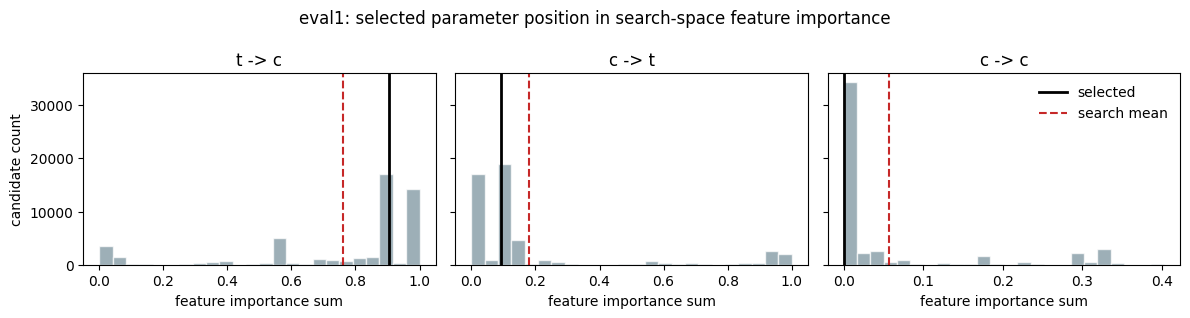

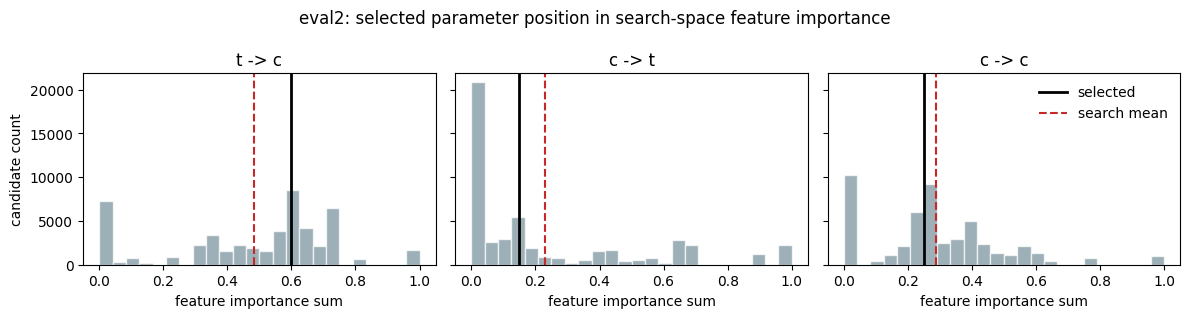

In [4]:
search = {
    "eval1": pd.read_csv(OUT_DIR / "eval1_hyperparameter_search.csv"),
    "eval2": pd.read_csv(OUT_DIR / "eval2_hyperparameter_search.csv"),
}

for eval_name, df in search.items():
    pos = pd.read_csv(OUT_DIR / f"{eval_name}_feature_family_distribution.csv").set_index("family")
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
    for ax, col, label in zip(
        axes,
        ["sum_t_to_c", "sum_c_to_t", "sum_c_to_c"],
        ["t -> c", "c -> t", "c -> c"],
    ):
        ax.hist(df[col], bins=24, color="#78909c", alpha=0.72, edgecolor="white")
        ax.axvline(pos.loc[label, "selected"], color="black", linewidth=2, label="selected")
        ax.axvline(pos.loc[label, "mean"], color="#c62828", linestyle="--", linewidth=1.5, label="search mean")
        ax.set_title(label)
        ax.set_xlabel("feature importance sum")
    axes[0].set_ylabel("candidate count")
    axes[-1].legend(frameon=False, loc="upper right")
    fig.suptitle(f"{eval_name}: selected parameter position in search-space feature importance")
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"{eval_name}_feature_family_distribution.png", dpi=160)
    plt.show()

## Simple Robustness / Overfitting Diagnostics

This section provides a lightweight robustness and overfitting diagnostic for the selected hyperparameters. It is not intended to prove external generalization. Instead, it is used as a sanity check to see whether the selected decision tree is unusually unstable within the available dataset, or whether its apparent performance is mainly driven by fitting the training samples too closely.

### What This Evaluates

- `train_loocv_accuracy_gap`: For each role set, this compares the accuracy of a tree fitted on all samples with the LOOCV accuracy. A larger gap suggests that the tree may fit the training data better than held-out samples.
- `repeated 5-fold accuracy`: This checks whether the result is overly sensitive to how the folds are split. A smaller standard deviation indicates more stable behavior across repeated CV splits.
- `label-permutation null`: This compares the observed score with a null model obtained by shuffling labels. If the observed score is clearly above the null distribution, the model is capturing signal beyond random labels.
- `local hyperparameter sensitivity`: This checks whether nearby hyperparameter settings preserve similar accuracy and REV F1. If the selected setting is the only high-performing point, the result is less robust.

### Where To Look

- Start with `loocv_accuracy_mean`, `loocv_accuracy_worst`, `loocv_rev_f1_mean`, and `loocv_rev_f1_worst` in the summary table. The worst-case values matter because a good mean can still hide unstable role sets.
- Then check `train_loocv_accuracy_gap_mean` and `train_loocv_accuracy_gap_max` in the summary table. These are aggregate values derived from the per-role-set train-LOOCV gaps; `train_loocv_accuracy_gap_max` corresponds to the largest bar in the top-left plot, not to a separate plotted series.
- `repeated_cv_accuracy_std` and `repeated_cv_rev_f1_std` summarize sensitivity to fold construction. Larger values mean the result is more affected by the small-sample setting.
- `permutation_p_accuracy`, `permutation_p_macro_f1`, and `permutation_p_rev_f1` are auxiliary checks against the label-permutation null. With 100 permutations, the minimum possible p-value is `1 / 101 = 0.0099`.
- In the plots, look for small per-role-set train-LOOCV gaps in the top-left panel, a narrow repeated 5-fold distribution in the top-right panel, an observed mean clearly to the right of the null distribution in the bottom-left panel, and a selected point that is not isolated from its local hyperparameter neighborhood in the bottom-right panel.

### Overall Assessment

- `eval1`: robust / no obvious overfitting. The LOOCV mean and worst-case scores are stable, and the train-LOOCV gap is small. This suggests that the selected hyperparameters lie in a relatively stable region.
- `eval2`: signal exists, but robustness is weaker; mild overfitting/instability warning. The scores are still clearly separated from the null model, so there is meaningful signal. However, because `eval2` has fewer samples than `eval1`, it is more sensitive to fold construction and role-set variation. This weaker stability should be treated as a limitation caused largely by the available sample size, rather than as evidence that the signal disappears.


In [5]:
robustness = pd.read_csv(OUT_DIR / "eval1_eval2_robustness_summary.csv")
display(robustness.round(4))

,eval_name,selected_params,loocv_accuracy_mean,loocv_accuracy_worst,loocv_rev_f1_mean,loocv_rev_f1_worst,train_loocv_accuracy_gap_mean,train_loocv_accuracy_gap_max,repeated_cv_accuracy_mean,repeated_cv_accuracy_std,...,repeated_cv_rev_f1_std,null_accuracy_mean,null_rev_f1_mean,local_accuracy_mean_min,local_accuracy_mean_max,selected_local_accuracy_mean,selected_local_rev_f1_mean,permutation_p_accuracy,permutation_p_macro_f1,permutation_p_rev_f1
0,eval1,"{""ccp_alpha"": 0.0, ""class_weight"": ""balanced"",...",0.7308,0.6684,0.7055,0.6242,0.0410,0.1070,0.7042,0.0103,...,0.0121,0.4965,0.4765,0.6979,0.7424,0.7308,0.7055,0.0099,0.0099,0.0099
1,eval2,"{""ccp_alpha"": 0.005, ""class_weight"": ""balanced...",0.6803,0.5849,0.5776,0.4771,0.1038,0.1761,0.6455,0.0152,...,0.0188,0.5044,0.4185,0.6468,0.6803,0.6803,0.5776,0.0099,0.0099,0.0099


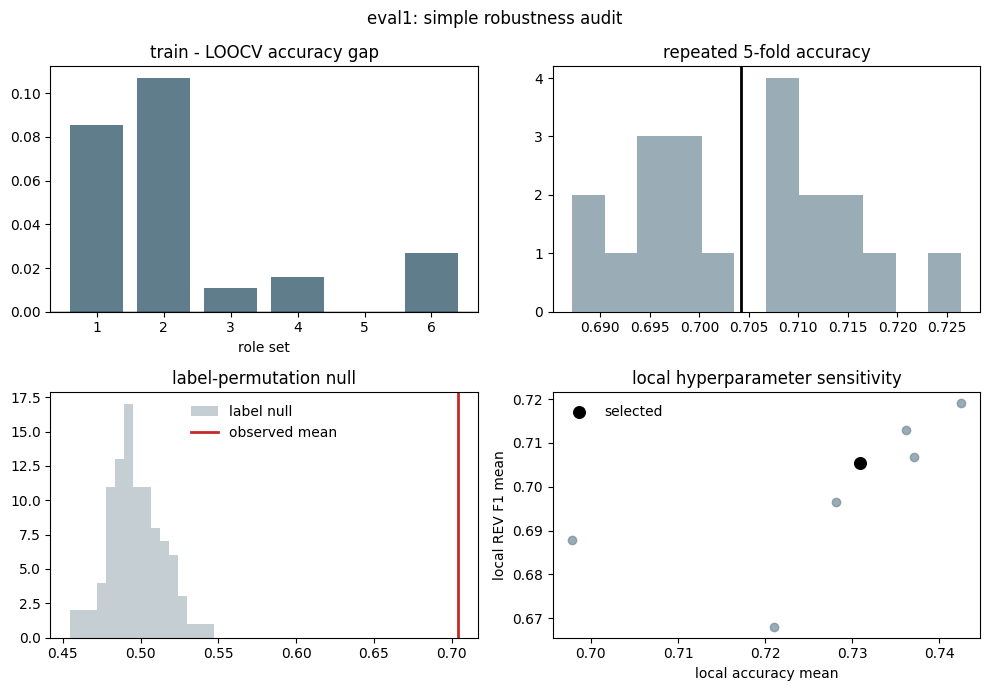

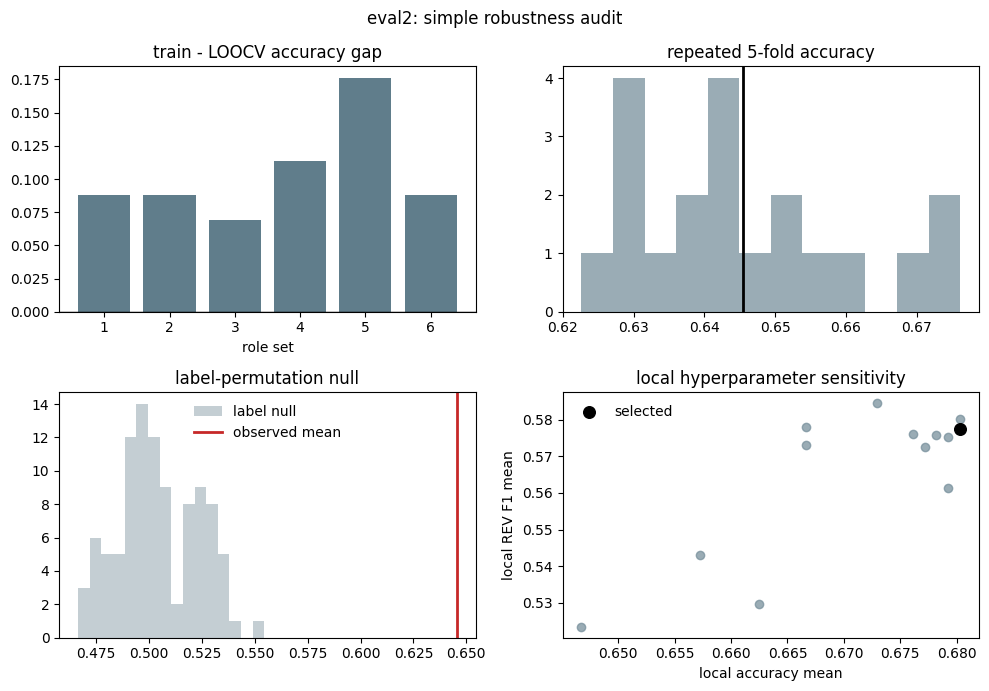

In [6]:
for eval_name in ["eval1", "eval2"]:
    per_set = pd.read_csv(OUT_DIR / f"{eval_name}_robustness_per_set.csv")
    cv_dist = pd.read_csv(OUT_DIR / f"{eval_name}_robustness_cv_dist.csv")
    null_dist = pd.read_csv(OUT_DIR / f"{eval_name}_robustness_null_dist.csv")
    local = pd.read_csv(OUT_DIR / f"{eval_name}_robustness_local_sensitivity.csv")
    selected = local[local["is_selected_exact_params"]].iloc[0]

    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    ax = axes[0, 0]
    ax.bar(per_set["set"].astype(str), per_set["train_loocv_accuracy_gap"], color="#607d8b")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title("train - LOOCV accuracy gap")
    ax.set_xlabel("role set")

    ax = axes[0, 1]
    ax.hist(cv_dist["accuracy_mean"], bins=12, alpha=0.75, color="#78909c")
    ax.axvline(cv_dist["accuracy_mean"].mean(), color="black", linewidth=2)
    ax.set_title("repeated 5-fold accuracy")

    ax = axes[1, 0]
    ax.hist(null_dist["accuracy"], bins=16, alpha=0.75, color="#b0bec5", label="label null")
    ax.axvline(cv_dist["accuracy_mean"].mean(), color="#c62828", linewidth=2, label="observed mean")
    ax.set_title("label-permutation null")
    ax.legend(frameon=False)

    ax = axes[1, 1]
    ax.scatter(local["accuracy_mean"], local["rev_f1_mean"], color="#78909c", alpha=0.75)
    ax.scatter([selected["accuracy_mean"]], [selected["rev_f1_mean"]], color="black", s=70, label="selected")
    ax.set_xlabel("local accuracy mean")
    ax.set_ylabel("local REV F1 mean")
    ax.set_title("local hyperparameter sensitivity")
    ax.legend(frameon=False)

    fig.suptitle(f"{eval_name}: simple robustness audit")
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"{eval_name}_robustness_summary.png", dpi=160)
    plt.show()

## CLI

The same implementation can be run from a terminal:

```bash
venv/bin/python decision_tree_hyperparameter_search.py --eval all
```

Useful options:

```bash
venv/bin/python decision_tree_hyperparameter_search.py --eval eval1 --skip-robustness
venv/bin/python decision_tree_hyperparameter_search.py --eval eval2 --force
```


In [7]:
for path in sorted(OUT_DIR.glob("*.csv")):
    print(path.relative_to(ROOT))

decision_tree_hparam_search_out/eval1_eval2_feature_family_distribution.csv
decision_tree_hparam_search_out/eval1_eval2_robustness_summary.csv
decision_tree_hparam_search_out/eval1_eval2_selected_feature_family_by_set.csv
decision_tree_hparam_search_out/eval1_feature_family_distribution.csv
decision_tree_hparam_search_out/eval1_hyperparameter_search.csv
decision_tree_hparam_search_out/eval1_robustness_cv_dist.csv
decision_tree_hparam_search_out/eval1_robustness_local_sensitivity.csv
decision_tree_hparam_search_out/eval1_robustness_null_dist.csv
decision_tree_hparam_search_out/eval1_robustness_per_set.csv
decision_tree_hparam_search_out/eval1_robustness_summary.csv
decision_tree_hparam_search_out/eval1_selected_feature_family_by_set.csv
decision_tree_hparam_search_out/eval2_feature_family_distribution.csv
decision_tree_hparam_search_out/eval2_hyperparameter_search.csv
decision_tree_hparam_search_out/eval2_robustness_cv_dist.csv
decision_tree_hparam_search_out/eval2_robustness_local_sens